<a href="https://colab.research.google.com/github/Thrysoe/north_diagnostics/blob/main/extract_all_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

fatal: destination path 'north_diagnostics' already exists and is not an empty directory.
🔄 Accessing cached data for Shot #9774 : Probe 1
🔄 Accessing cached data for Shot #9774 : Probe 2
🔄 Accessing cached data for Shot #9774 : Probe 3
🔄 Accessing cached data for Shot #9774 : Probe 4
🔄 Accessing cached data for Shot #9774 : Probe 5
🔄 Accessing cached data for Shot #9774 : Probe 6
🔄 Accessing cached data for Shot #9774 : Probe 7
🔄 Accessing cached data for Shot #9774 : Probe 8
🔄 Accessing cached data for Shot #9774 : Probe 9
🔄 Accessing cached data for Shot #9774 : Probe 10
🔄 Accessing cached data for Shot #9774 : Probe 11
🔄 Accessing cached data for Shot #9774 : Probe 13
🔄 Accessing cached data for Shot #9774 : Probe 14
🔄 Accessing cached data for Shot #9774 : Probe 15
🔄 Accessing cached data for Shot #9774 : Probe 16
🔄 Accessing cached data for Shot #9774 : Probe 17
🔄 Accessing cached data for Shot #9774 : Probe 18
🔄 Accessing cached data for Shot #9774 : Probe 19


/tmp/ipython-input-1822211682.py:85: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(current_fit, U[start:end], I[start:end], guess)


🔄 Accessing cached data for Shot #9774 : Probe 20
🔄 Accessing cached data for Shot #9774 : Probe 21
🔄 Accessing cached data for Shot #9774 : Probe 22
🔄 Accessing cached data for Shot #9774 : Probe 23
🔄 Accessing cached data for Shot #9774 : Probe 24
🔄 Accessing cached data for Shot #9774 : Probe 25
🔄 Accessing cached data for Shot #9774 : Probe 26
🔄 Accessing cached data for Shot #9774 : Probe 27
🔄 Accessing cached data for Shot #9774 : Probe 29
🔄 Accessing cached data for Shot #9774 : Probe 30
🔄 Accessing cached data for Shot #9774 : Probe 31
🔄 Accessing cached data for Shot #9774 : Probe 32
🔄 Accessing cached data for Shot #9774 : Probe 33
🔄 Accessing cached data for Shot #9774 : Probe 38
🔄 Accessing cached data for Shot #9774 : Probe 39
🔄 Accessing cached data for Shot #9774 : Probe 40
🔄 Accessing cached data for Shot #9774 : Probe 41
🔄 Accessing cached data for Shot #9774 : Probe 42
🔄 Accessing cached data for Shot #9774 : Probe 43
🔄 Accessing cached data for Shot #9774 : Probe 44


/tmp/ipython-input-1822211682.py:23: RuntimeWarning: overflow encountered in exp
  return I_isat*(np.exp(e0*(U-U_f)/k_BT_e)-1)


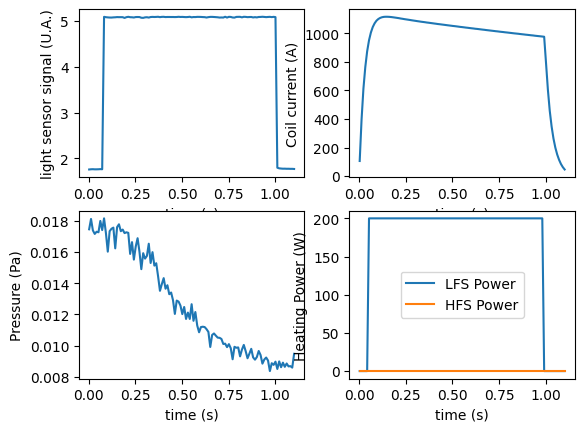

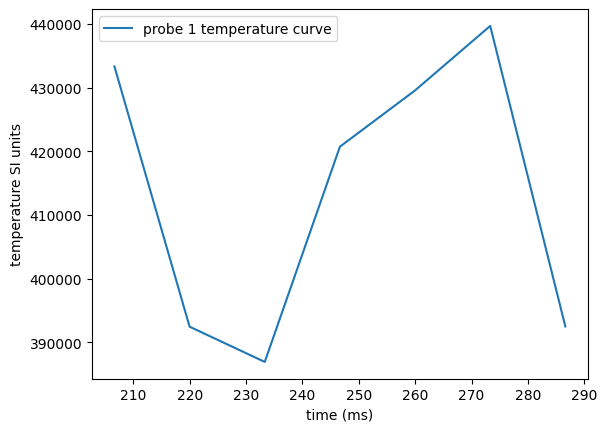

<Figure size 640x480 with 0 Axes>

In [43]:
"""
Extract all data from the DDAQ and CRIO files and plot it. Both .tdms file must be saved in the data folder, but there is a possibility to change the path file
at the beginning of the main program.
Usefull for further data treatment and save all usefull data in a .txt file.
Define shot number just after the main programm begins.
"""

#Import all useful libraries

!git clone https://github.com/thrysoe/north_diagnostics.git -q
!pip install nptdms -q

import nptdms
from scipy.optimize import curve_fit
from north_diagnostics.diagnostics import Probe, Diagnostic
import matplotlib.pyplot as plt
import numpy as np

# Define all useful functions
def current_fit(U, I_isat, k_BT_e, U_f):
  """Function fitted by scipy in the transition function of the I-V curve for electron temperature measurements"""
  e0 = 1.602E-19 # in C
  return I_isat*(np.exp(e0*(U-U_f)/k_BT_e)-1)

def read_machine_data(shot, path_to_data):
  """
  Read the channels:  1 (Light sensor)
                      2 (Coil currents)
                      3 (Pressure sensor)
                      6 (LFS power)
                      7 (HFS power)
  to control machine parameters. Plotted in the main program and saved in a .txt files in the Data folder.
  """
  #Read data file
  file = nptdms.TdmsFile.read(f"{path_to_data}/CRIO{shot}.tdms")

  #Define the time interval of the study (the mask variable)
  t_start = 0
  t_end = file['Data']['Time'][-1]
  mask = (file['Data']['Time'][:] >= t_start) & (file['Data']['Time'][:] <= t_end)

  #Extracting all machine parameters
  t = file['Data']['Time'][mask]
  data = np.zeros((len(t), 6))
  head = 'Time; Light sensor; Coil current; Pressure sensor; LFS power; HFS power'
  data[:,0] = t*1E-6 # in s
  data[:,1] = file['Data']['Light'][mask] # in ??; whatever, not for a quantitative analysis
  data[:,2] = file['Data']['I_TF'][mask] # in A
  data[:,3] = file['Data']['Pressure'][mask]*1E2 # in Pa
  data[:,4] = file['Data']['LFSset'][mask]*450/3000 # in W
  data[:,5] = file['Data']['HFSset'][mask]*450/3000 # in W
  return data

def read_probe_data(shot, path_to_data, m_i, A, T_sweep, k_B, e, studdied_channels):
  """
  Read all the probes channels which are n_channel=n_probe+14. The read channels can be selected at the beginning of the main program.
  Saved in a .txt files in the Data folder.
  """
  #Initialisation of probe variable
  probe = {}
  t_start = 200E-3
  t_end = 300E-3

  #Read data file
  for i in studdied_channels:
    probe[i] = Probe(path = path_to_data, shot = shot, number = i+1, caching = True)
    if i==0:
      ind_start, ind_end = probe[i].get_time_indices(t_start, t_end)
    t = probe[i].time[ind_start:ind_end]
    U = probe[i].bias_voltage[ind_start:ind_end]
    I = probe[i].current[ind_start:ind_end]
    if bias_type == 'density':
      if i==0:
        data = np.zeros((len(t), 51))
        data[:,0] = t
      data[:,i+1] = -I/(0.61*e*np.sqrt(k_B*T_e_estim/m_i)*A)
    elif bias_type == 'temperature':
      if i==0:
        N = int((t_end-t_start)/T_sweep) #Number of temperature measurements possible, take a full sweep to be unbothered by hysterisis effects
        data = np.zeros((N, 51))
        data[:,0] = np.array(range(N))*T_sweep + T_sweep/2 + t_start
      for j in range(N):
        start, end = probe[i].get_time_indices(j*T_sweep, (j+1)*T_sweep)
        guess = [0.0001, 1E-18, 10]
        popt, pcov = curve_fit(current_fit, U[start:end], I[start:end], guess)
        data[j,i+1] = popt[1]/k_B
    else:
      print('WARNING: the bias type is not recognized')
      exit()
  return data

#Main program: plot all machine and some probe data to verify that the shot "looks fine"
if __name__=="__main__":
  #Input parameters
  shot = 9774
  A_gas = 4 #Helium 4
  T_sweep = 13.33E-3 #period of the sweep for electronic temperature measurements in s
  bias_type = 'temperature' #Probes can be biased to measure 'density' or 'temperature' (the same bias is applied on every probe)
  #you should only select non null channels
  studdied_channels=np.array([1,2,3,4,5,6,7,8,9,10,11,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,29,30,31,32,33,38,39,40,41,42,43,44,46,47,48,49])-1
  path_to_data = './north_diagnostics/Data/'
  path_to_figure = './north_diagnostics/Figures/'

  #Physical constants
  e = 1.602E-19 # in C
  k_B = 1.38E-23 # in J/K
  m_i = A_gas*1.67E-27 # ion mass in kg

  #Experiment parameters
  A = 1E-6 # probe surface in m^2
  T_e_estim = 10*e/k_B # estimate of temperature in K (the numerical value is in eV) to measure electron density

  #Generate the data
  machine_data = read_machine_data(shot, path_to_data)
  probe_data = read_probe_data(shot, path_to_data, m_i, A, T_sweep, k_B, e, studdied_channels)

  #Saving all data in the Data folder
  head = 'Time; Light sensor; Coil current; Pressure sensor; LFS power; HFS power in SI units'
  np.savetxt(f"{path_to_data}machine_data{shot}.txt", machine_data, delimiter=';', header=head)
  head = 'Time; probes in the numerical order in SI units'
  np.savetxt(f"{path_to_data}probe_data{shot}.txt", probe_data, delimiter=';', header=head)

  #Plot and save figures
  plt.subplot(2,2,1)
  plt.plot(machine_data[:,0]*1E3, machine_data[:,1])
  plt.xlabel('time (s)')
  plt.ylabel('light sensor signal (U.A.)')

  plt.subplot(2,2,2)
  plt.plot(machine_data[:,0]*1E3, machine_data[:,2])
  plt.xlabel('time (s)')
  plt.ylabel('Coil current (A)')

  plt.subplot(2,2,3)
  plt.plot(machine_data[:,0]*1E3, machine_data[:,3])
  plt.xlabel('time (s)')
  plt.ylabel('Pressure (Pa)')

  plt.subplot(2,2,4)
  plt.plot(machine_data[:,0]*1E3, machine_data[:,4], label='LFS Power')
  plt.plot(machine_data[:,0]*1E3, machine_data[:,5], label='HFS Power')
  plt.xlabel('time (s)')
  plt.ylabel('Heating Power (W)')

  plt.legend()
  plt.show()
  plt.savefig(f"{path_to_figure}/machine_data{shot}")

  plt.plot(probe_data[:,0]*1E3, probe_data[:,1], label='probe 1 '+bias_type+' curve')
  plt.xlabel('time (ms)')
  plt.ylabel(bias_type +' SI units')
  plt.legend()
  plt.show()
  plt.savefig(f"{path_to_figure}/ex_probe_data{shot}")